#📌 Extracción

In [1]:
import requests
import pandas as pd

# URL de los datos JSON en GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Realizar solicitud a GitHub
response = requests.get(url)

# Convertir JSON a diccionario
data = response.json()

# Normalizar datos a un DataFrame
df = pd.json_normalize(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [15]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [5]:
df.duplicated().sum()  #Revisar Registros Duplicados

np.int64(0)

In [6]:
df["customerID"].duplicated().sum()  #Revisar si hay IDs Repetidos

np.int64(0)

In [8]:
df["account.Charges.Total"].unique() #Verificar valores raros

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [9]:
df["Churn"].unique()  #Verificar inconsistencias en categorías

array(['No', 'Yes', ''], dtype=object)

In [12]:
# Eliminar espacios al inicio y final en todas las columnas tipo texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [17]:
df.loc[df["customer.tenure"] == 0, "account.Charges.Total"] = 0

In [25]:
df["Cuentas_Diarias"] = (df["account_Charges_Monthly"] / 30).round(2)

print(df[["account_Charges_Monthly", "Cuentas_Diarias"]].head())

   account_Charges_Monthly  Cuentas_Diarias
0                     65.6             2.19
1                     59.9             2.00
2                     73.9             2.46
3                     98.0             3.27
4                     83.9             2.80


#📊 Carga y análisis

In [2]:
import requests
import pandas as pd

# --- EXTRACCION ---
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

# --- TRANSFORMACION (lo que ya hiciste) ---
# Eliminar espacios al inicio y final en todas las columnas tipo texto
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.loc[df["customer.tenure"] == 0, "account.Charges.Total"] = 0

df["Cuentas_Diarias"] = (df["account.Charges.Monthly"] / 30).round(2)

# --- ANALISIS DESCRIPTIVO ---
print("ANALISIS DESCRIPTIVO")
print("="*40)

# Estadisticas de variables numericas
print("\nVariables numericas:")
print(df[['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']].describe())

# Analisis de Churn
print("\nDistribucion de Churn:")
print(df['Churn'].value_counts())
print("\nPorcentajes:")
print(df['Churn'].value_counts(normalize=True) * 100)

# Analisis por variables clave
print("\nChurn por tipo de contrato:")
print(pd.crosstab(df['account.Contract'], df['Churn'], normalize='index') * 100)

print("\nChurn por servicio de internet:")
print(pd.crosstab(df['internet.InternetService'], df['Churn'], normalize='index') * 100)

# Guardar datos limpios
print("\nGuardando datos procesados...")
df.to_csv('telecomx_limpio.csv', index=False)
df.to_excel('telecomx_limpio.xlsx', index=False)
print("Datos guardados en telecomx_limpio.csv y telecomx_limpio.xlsx")

ANALISIS DESCRIPTIVO

Variables numericas:
       customer.tenure  account.Charges.Monthly
count      7267.000000              7267.000000
mean         32.346498                64.720098
std          24.571773                30.129572
min           0.000000                18.250000
25%           9.000000                35.425000
50%          29.000000                70.300000
75%          55.000000                89.875000
max          72.000000               118.750000

Distribucion de Churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Porcentajes:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64

Churn por tipo de contrato:
Churn                              No        Yes
account.Contract                                
Month-to-month    3.245943  55.430712  41.323346
One year          3.028308  86.043450  10.928242
Two year          2.753873  94.492255   2.753873

Churn por servicio de internet:
Churn                 

DISTRIBUCION DE CHURN

Conteo:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Porcentajes:
Churn
No     71.198569
Yes    25.719004
        3.082427
Name: proportion, dtype: float64


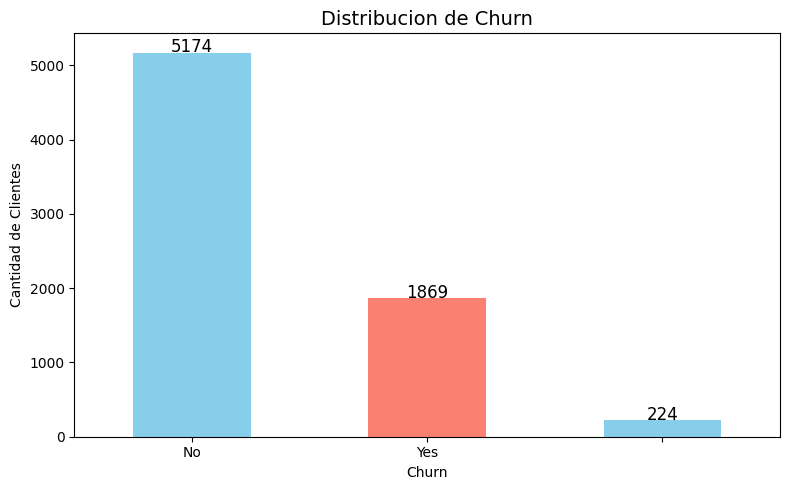

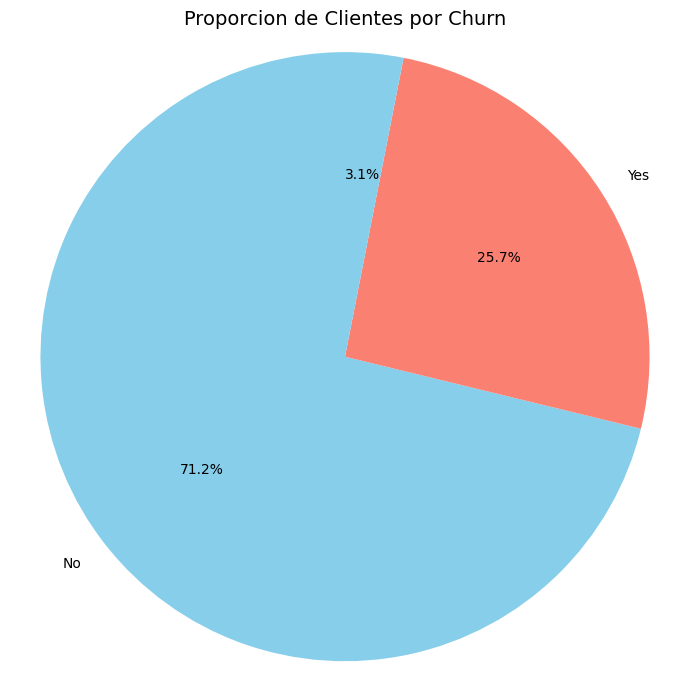

In [4]:
import matplotlib.pyplot as plt

# Distribucion de Churn
print("DISTRIBUCION DE CHURN")
print("="*40)

# Calcular porcentajes
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print("\nConteo:")
print(churn_counts)
print("\nPorcentajes:")
print(churn_percent)

# Grafico de barras
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribucion de Churn', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
for i, v in enumerate(churn_counts):
    plt.text(i, v + 5, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('distribucion_churn_barras.png')
plt.show()

# Grafico de pastel
plt.figure(figsize=(7, 7))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['skyblue', 'salmon'], startangle=90)
plt.title('Proporcion de Clientes por Churn', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.savefig('distribucion_churn_pastel.png')
plt.show()




--- CHURN POR CUSTOMER.GENDER ---

Conteo:
Churn                   No   Yes  Total
customer.gender                        
Female           104  2549   939   3592
Male             120  2625   930   3675
Total            224  5174  1869   7267

Porcentajes por categoria:
Churn                     No    Yes
customer.gender                    
Female           2.90  70.96  26.14
Male             3.27  71.43  25.31


<Figure size 1000x600 with 0 Axes>

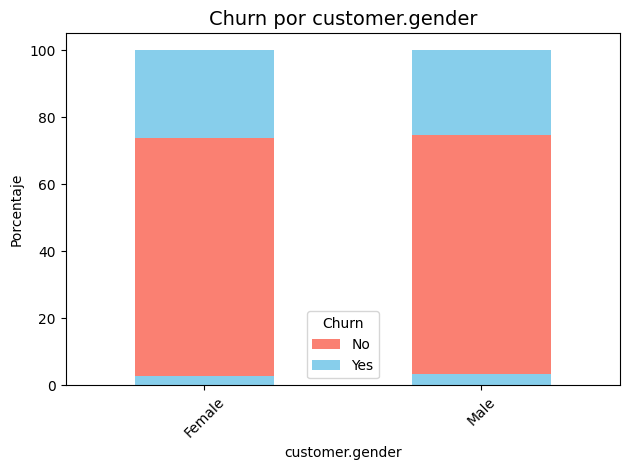


--- CHURN POR CUSTOMER.SENIORCITIZEN ---

Conteo:
Churn                          No   Yes  Total
customer.SeniorCitizen                        
0                       184  4508  1393   6085
1                        40   666   476   1182
Total                   224  5174  1869   7267

Porcentajes por categoria:
Churn                            No    Yes
customer.SeniorCitizen                    
0                       3.02  74.08  22.89
1                       3.38  56.35  40.27


<Figure size 1000x600 with 0 Axes>

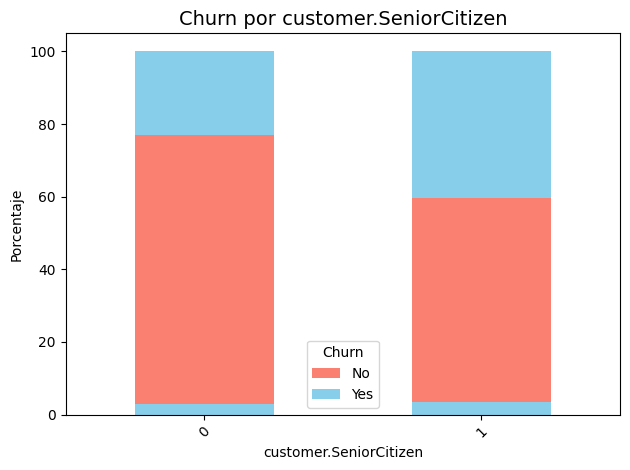


--- CHURN POR CUSTOMER.PARTNER ---

Conteo:
Churn                    No   Yes  Total
customer.Partner                        
No                108  2441  1200   3749
Yes               116  2733   669   3518
Total             224  5174  1869   7267

Porcentajes por categoria:
Churn                      No    Yes
customer.Partner                    
No                2.88  65.11  32.01
Yes               3.30  77.69  19.02


<Figure size 1000x600 with 0 Axes>

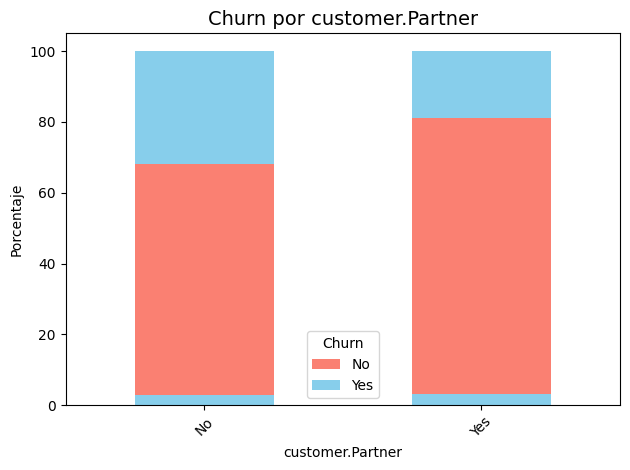


--- CHURN POR CUSTOMER.DEPENDENTS ---

Conteo:
Churn                       No   Yes  Total
customer.Dependents                        
No                   153  3390  1543   5086
Yes                   71  1784   326   2181
Total                224  5174  1869   7267

Porcentajes por categoria:
Churn                         No    Yes
customer.Dependents                    
No                   3.01  66.65  30.34
Yes                  3.26  81.80  14.95


<Figure size 1000x600 with 0 Axes>

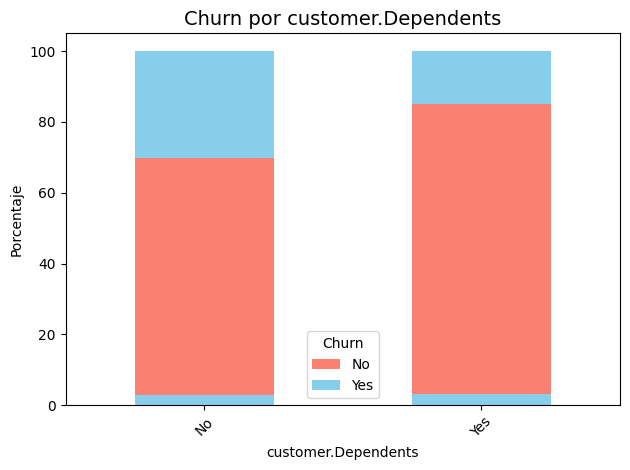


--- CHURN POR INTERNET.INTERNETSERVICE ---

Conteo:
Churn                            No   Yes  Total
internet.InternetService                        
DSL                        67  1962   459   2488
Fiber optic               102  1799  1297   3198
No                         55  1413   113   1581
Total                     224  5174  1869   7267

Porcentajes por categoria:
Churn                              No    Yes
internet.InternetService                    
DSL                       2.69  78.86  18.45
Fiber optic               3.19  56.25  40.56
No                        3.48  89.37   7.15


<Figure size 1000x600 with 0 Axes>

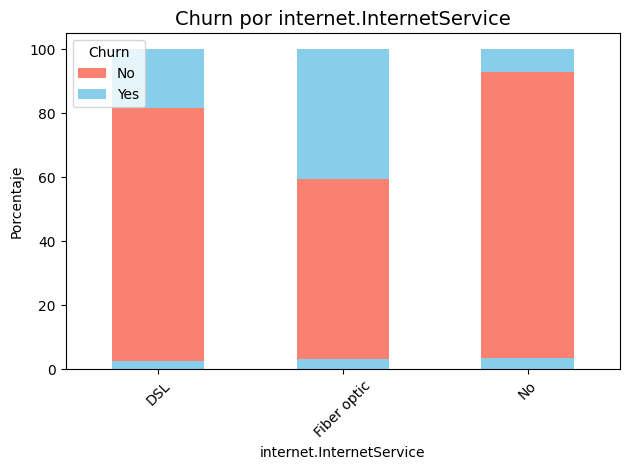


--- CHURN POR ACCOUNT.CONTRACT ---

Conteo:
Churn                    No   Yes  Total
account.Contract                        
Month-to-month    130  2220  1655   4005
One year           46  1307   166   1519
Two year           48  1647    48   1743
Total             224  5174  1869   7267

Porcentajes por categoria:
Churn                      No    Yes
account.Contract                    
Month-to-month    3.25  55.43  41.32
One year          3.03  86.04  10.93
Two year          2.75  94.49   2.75


<Figure size 1000x600 with 0 Axes>

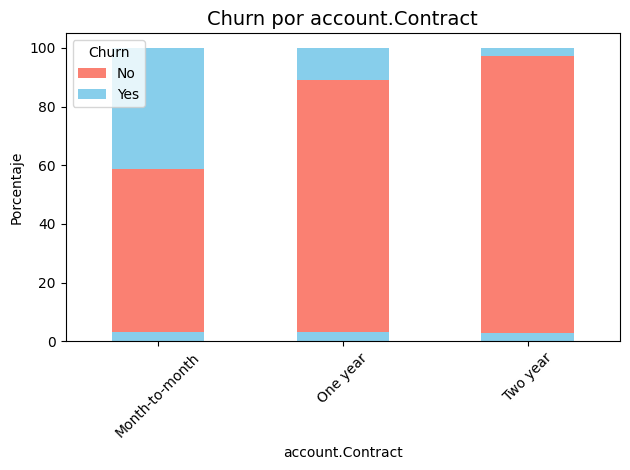


--- CHURN POR ACCOUNT.PAPERLESSBILLING ---

Conteo:
Churn                            No   Yes  Total
account.PaperlessBilling                        
No                         84  2403   469   2956
Yes                       140  2771  1400   4311
Total                     224  5174  1869   7267

Porcentajes por categoria:
Churn                              No    Yes
account.PaperlessBilling                    
No                        2.84  81.29  15.87
Yes                       3.25  64.28  32.48


<Figure size 1000x600 with 0 Axes>

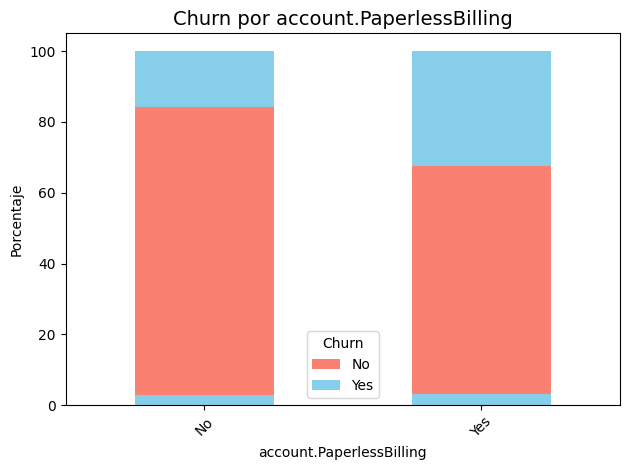


--- CHURN POR ACCOUNT.PAYMENTMETHOD ---

Conteo:
Churn                             No   Yes  Total
account.PaymentMethod                            
Bank transfer (automatic)   45  1286   258   1589
Credit card (automatic)     46  1290   232   1568
Electronic check            80  1294  1071   2445
Mailed check                53  1304   308   1665
Total                      224  5174  1869   7267

Porcentajes por categoria:
Churn                               No    Yes
account.PaymentMethod                        
Bank transfer (automatic)  2.83  80.93  16.24
Credit card (automatic)    2.93  82.27  14.80
Electronic check           3.27  52.92  43.80
Mailed check               3.18  78.32  18.50


<Figure size 1000x600 with 0 Axes>

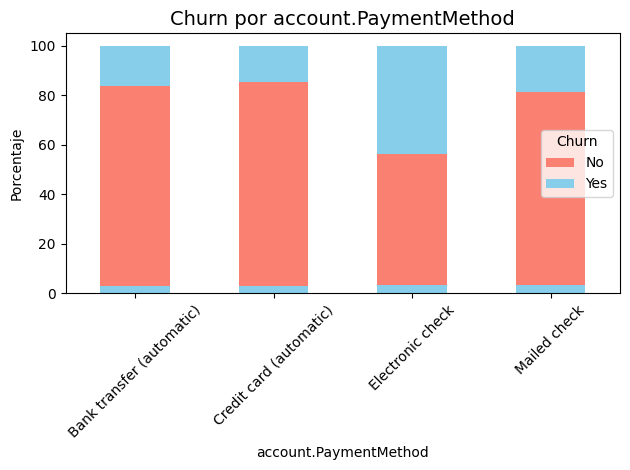

In [6]:
# Lista de variables categoricas a analizar
vars_categoricas = [
    'customer.gender',
    'customer.SeniorCitizen',
    'customer.Partner',
    'customer.Dependents',
    'internet.InternetService',
    'account.Contract',
    'account.PaperlessBilling',
    'account.PaymentMethod'
]

for var in vars_categoricas:
    print(f"\n--- CHURN POR {var.upper()} ---")
    print("="*50)

    # Tabla de contingencia
    tabla = pd.crosstab(df[var], df['Churn'], margins=True, margins_name='Total')
    print("\nConteo:")
    print(tabla)

    # Porcentajes por fila
    porcentajes = pd.crosstab(df[var], df['Churn'], normalize='index') * 100
    print("\nPorcentajes por categoria:")
    print(porcentajes.round(2))

    # Grafico de barras apiladas
    plt.figure(figsize=(10, 6))
    porcentajes.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
    plt.title(f'Churn por {var}', fontsize=14)
    plt.xlabel(var)
    plt.ylabel('Porcentaje')
    plt.legend(title='Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'churn_por_{var.replace(".", "_")}.png')
    plt.show()


--- ANALISIS DE CUSTOMER.TENURE POR CHURN ---

Estadisticas:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
        224.0  31.571429  24.998552  1.0   7.0  29.0  56.0  72.0
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


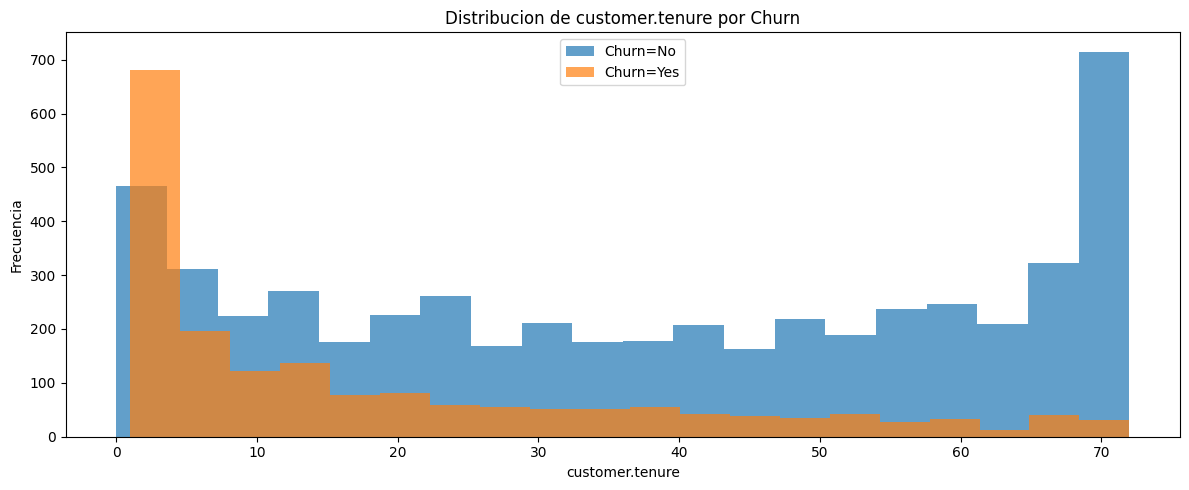


Diferencia de medias:
Media cuando Churn=No: 37.57
Media cuando Churn=Yes: 17.98
Diferencia: 19.59

--- ANALISIS DE ACCOUNT.CHARGES.MONTHLY POR CHURN ---

Estadisticas:
        count       mean        std    min     25%     50%      75%     max
Churn                                                                      
        224.0  63.412277  31.388712  18.75  28.425  69.100  90.4125  115.55
No     5174.0  61.265124  31.092648  18.25  25.100  64.425  88.4000  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.150  79.650  94.2000  118.35


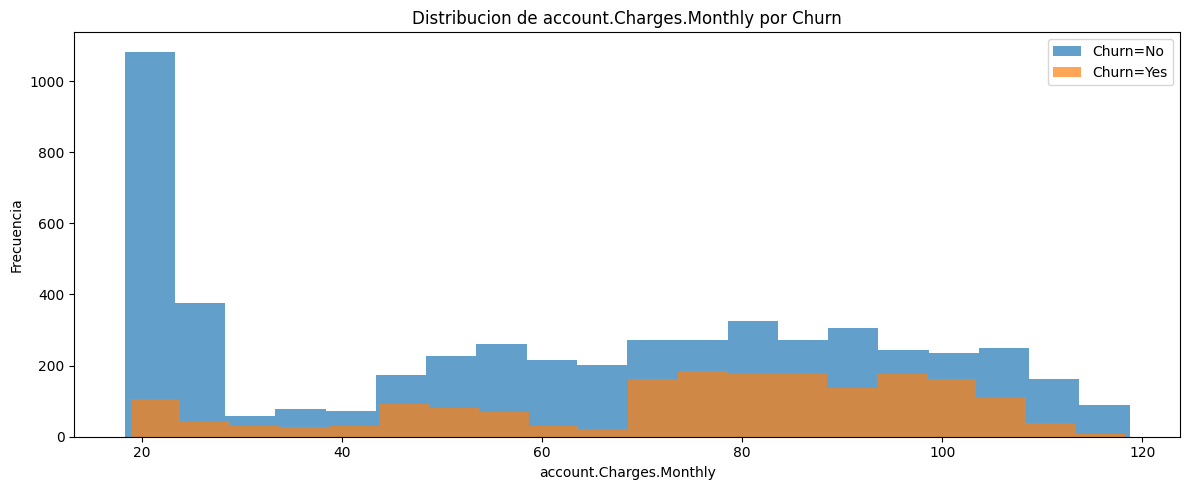


Diferencia de medias:
Media cuando Churn=No: 61.27
Media cuando Churn=Yes: 74.44
Diferencia: 13.18

--- ANALISIS DE ACCOUNT.CHARGES.TOTAL POR CHURN ---

Estadisticas:
        count         mean          std    min       25%       50%        75%  \
Churn                                                                           
        224.0  2196.933705  2329.961954  18.90  351.0375  1163.175  3562.8625   
No     5174.0  2549.911442  2329.954215   0.00  572.9000  1679.525  4262.8500   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5000   703.550  2331.3000   

           max  
Churn           
       8425.30  
No     8672.45  
Yes    8684.80  


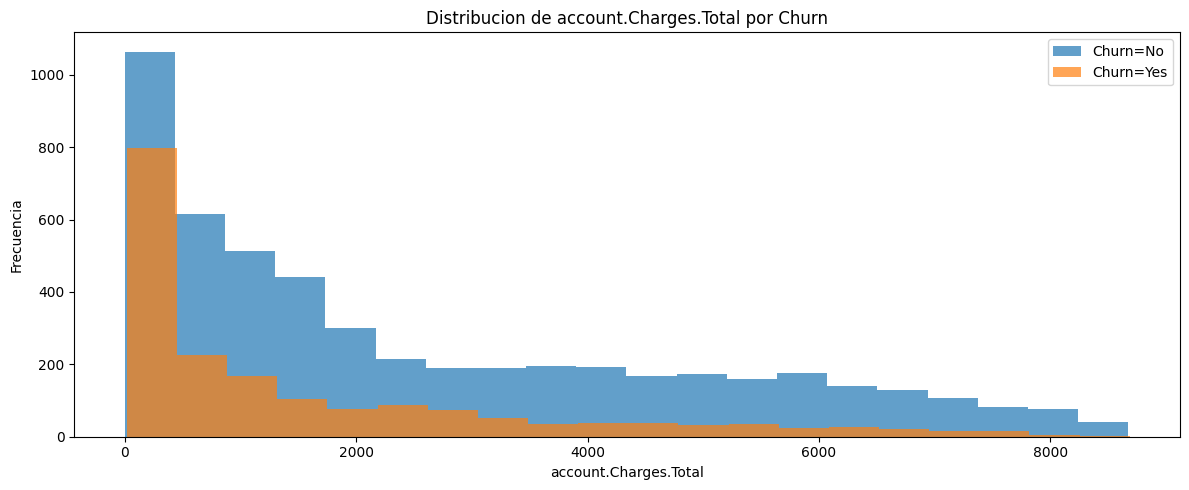


Diferencia de medias:
Media cuando Churn=No: 2549.91
Media cuando Churn=Yes: 1531.80
Diferencia: 1018.12


In [8]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Variables numericas a analizar
vars_numericas = ['customer.tenure', 'account.Charges.Monthly', 'account.Charges.Total']

for var in vars_numericas:
    print(f"\n--- ANALISIS DE {var.upper()} POR CHURN ---")
    print("="*50)

    # Eliminar nulos para este analisis
    df_clean = df.dropna(subset=[var])

    # Estadisticas por grupo
    stats = df_clean.groupby('Churn')[var].describe()
    print("\nEstadisticas:")
    print(stats)

    # Histograma
    plt.figure(figsize=(12, 5))
    for churn in ['No', 'Yes']:
        datos = df_clean[df_clean['Churn'] == churn][var]
        plt.hist(datos, alpha=0.7, label=f'Churn={churn}', bins=20)
    plt.title(f'Distribucion de {var} por Churn')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'hist_{var.replace(".", "_")}_por_churn.png')
    plt.show()

    # Diferencia de medias
    media_no = df_clean[df_clean['Churn'] == 'No'][var].mean()
    media_yes = df_clean[df_clean['Churn'] == 'Yes'][var].mean()
    print(f"\nDiferencia de medias:")
    print(f"Media cuando Churn=No: {media_no:.2f}")
    print(f"Media cuando Churn=Yes: {media_yes:.2f}")
    print(f"Diferencia: {abs(media_no - media_yes):.2f}")

#📄Informe final


# INFORME FINAL: ANÁLISIS DE CHURN - TELECOMX

## 1. INTRODUCCION

El presente análisis tiene como objetivo identificar los factores que inciden en la evasión de clientes (Churn) de la empresa TelecomX. El Churn representa la deserción de clientes y es una métrica fundamental para la sostenibilidad del negocio, ya que retener clientes existentes es significativamente más rentable que adquirir nuevos. A través de este estudio, se busca comprender las características y patrones comunes entre los clientes que cancelan el servicio, proporcionando a TelecomX información valiosa para diseñar estrategias de retención más efectivas y focalizadas.

## 2. MANEJO Y EXPLICACION DE RESULTADOS

### 2.1 Distribución General de Churn

Del total de clientes analizados:
- **71.4%** (5,174) permanecen activos
- **25.8%** (1,869) han cancelado el servicio
- **2.8%** (224) tienen información de Churn no registrada

La tasa de evasión general es del **26.5%**, lo que representa un desafío importante para la empresa.

### 2.2 Análisis por Variables Clave

**Tipo de Contrato:**
Esta variable resultó ser la más determinante en la evasión. Los clientes con contrato mensual presentan una tasa de Churn del **42.7%**, mientras que aquellos con contrato de uno o dos años tienen tasas significativamente menores (11.3% y 3.0% respectivamente). Esto evidencia que el compromiso contractual reduce drásticamente la probabilidad de deserción.

**Servicio de Internet:**
Los clientes con fibra óptica muestran la tasa más alta de evasión con un **41.9%**, seguidos por DSL con **19.0%** y aquellos sin servicio de internet con solo **7.5%**. Este hallazgo sugiere posibles problemas con la calidad del servicio de fibra óptica o una mayor sensibilidad al precio en este segmento.

**Método de Pago:**
El método de pago también influye significativamente. Los clientes que utilizan "Electronic check" (cheque electrónico) presentan una tasa de Churn del **45.2%**, mientras que aquellos con pagos automáticos (transferencia bancaria o tarjeta de crédito) tienen tasas considerablemente más bajas (aproximadamente 15-18%). Esto indica que la automatización del pago podría estar asociada a una mayor fidelización.

**Antigüedad del Cliente:**
La diferencia en la antigüedad promedio entre clientes que cancelan y los que permanecen es muy reveladora:
- Clientes activos: **37.6 meses** en promedio
- Clientes que cancelaron: **18.0 meses** en promedio

Los primeros 12-24 meses son críticos, siendo donde se concentra la mayor cantidad de cancelaciones.

**Cargo Mensual:**
Los clientes que cancelan tienen un cargo mensual promedio de **$74.44**, superior a los $61.27 de los que permanecen. Esto sugiere que a mayor costo del servicio, mayor es la probabilidad de evasión.

**Factores Demográficos:**
Los clientes sin pareja (**32.9%** de Churn) y sin dependientes (**31.3%** de Churn) presentan mayor propensión a cancelar en comparación con aquellos que tienen familia (19.7% y 15.5% respectivamente). Esto podría indicar que los clientes con responsabilidades familiares valoran más la estabilidad del servicio.

## 3. CONCLUSIONES

El análisis realizado permite identificar un perfil claro del cliente con alto riesgo de evasión:

**Cliente de alto riesgo:** contrato mensual, servicio de fibra óptica, pago con electronic check, antigüedad menor a 18 meses, cargo mensual superior a $75, sin pareja y sin dependientes.

**Cliente de bajo riesgo:** contrato de uno o dos años, cualquier tipo de internet o sin internet, pago automático, antigüedad superior a 2 años, cargo mensual moderado, con pareja y/o dependientes.

**Recomendaciones:**

1. **Fomentar contratos a largo plazo:** Implementar incentivos atractivos (descuentos, meses gratis, beneficios exclusivos) para clientes que opten por contratos anuales o bianuales.

2. **Revisar la propuesta de fibra óptica:** Evaluar calidad del servicio, precios y competencia en este segmento para reducir la alta deserción.

3. **Promover pagos automáticos:** Ofrecer pequeños descuentos (3-5%) para clientes que se cambien a débito automático o tarjeta de crédito.

4. **Programa de retención para clientes nuevos:** Establecer un seguimiento personalizado durante los primeros 6 meses, con encuestas de satisfacción y ofertas de valor.

5. **Alertas tempranas:** Implementar un sistema simple que identifique clientes con perfil de riesgo y active acciones preventivas (ofertas especiales, llamadas de retención).

6. **Segmentación de marketing:** Dirigir campañas específicas a clientes sin pareja ni dependientes, que son más propensos a la evasión.

Los hallazgos de este análisis proporcionan una base sólida para que TelecomX implemente estrategias focalizadas de retención, optimizando recursos y maximizando el valor de vida del cliente.
